## <p style="text-align:center;">Employee Performance and Retention Analysis</p>
### **Objectives**
The primary objective of this assignment is to prepare datasets previously collected and analyzed on HR Analytics Employee Attrition & Performance for predictive modelling. This involves merging datasets, addressing data quality issues, and engineering new features to enhance model performance. Specifically, the goals are:

1. To merge multiple datasets into a cohesive dataset for analysis.
2. To handle missing values, outliers, and other data quality issues systematically.
3. To derive at least five new features to enrich the dataset.
4. To document the entire process clearly with Python code, observations, and visualizations.

### **1. Merging Related Datasets**

#### **Entity Relationships**

The datasets used in this assignment include:

1. **Employee.csv**: Contains information about employees.
2. **PerformanceRating.csv**: Includes employee performance metrics.
3. **EducationLevel.csv**: Maps education levels to descriptive labels.
4. **SatisfiedLevel.csv**: Maps satisfaction levels to descriptive labels.
5. **RatingLevel.csv**: Maps manager ratings to descriptive labels.

#### **Merge Plan**

The datasets are merged into smaller, related dataframes:

1. **EmployeePerformance**: Combines `Employee` and `PerformanceRating` on `EmployeeID`.
2. **EmployeeEducation**: Links `Employee` with `EducationLevel` on `Education`.
3. **EmployeeSatisfaction**: Links `EmployeePerformance` with `SatisfiedLevel` on `EnvironmentSatisfaction`.
4. **EmployeeRating**: Links `EmployeePerformance` with `RatingLevel` on `ManagerRating`.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Load datasets
employee_data = pd.read_csv("Employee.csv")
performance_data = pd.read_csv("PerformanceRating.csv")
education_level = pd.read_csv("EducationLevel.csv")
satisfaction_level = pd.read_csv("SatisfiedLevel.csv")
rating_level = pd.read_csv("RatingLevel.csv")

# Print data before merging
employee_data

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,Single,38508,0,No,2022-12-26,No,0,0,0,0
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,Single,92995,3,No,2022-12-30,No,0,0,0,0
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,Single,63375,0,No,2022-12-30,No,0,0,0,0
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,Married,46521,0,No,2022-12-30,No,0,0,0,0


In [2]:
# Print data before merging
performance_data

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,3/14/2016,5,3,3,3,1,5,5,4
6705,PR996,7C80-94E0,3/14/2016,3,5,4,2,1,3,4,4
6706,PR997,8233-2483,3/14/2016,3,4,2,3,1,2,3,2
6707,PR998,8A5B-3D6E,3/15/2016,5,2,5,2,2,4,3,3


In [3]:
# Print data before merging
education_level

,EducationLevelID,EducationLevel
0,1,No Formal Qualifications
1,2,High School
2,3,Bachelors
3,4,Masters
4,5,Doctorate


In [4]:
# Print data before merging
satisfaction_level

,SatisfactionID,SatisfactionLevel
0,1,Very Dissatisfied
1,2,Dissatisfied
2,3,Neutral
3,4,Satisfied
4,5,Very Satisfied


In [5]:
# Print data before merging
rating_level

,RatingID,RatingLevel
0,1,Unacceptable
1,2,Needs Improvement
2,3,Meets Expectation
3,4,Exceeds Expectation
4,5,Above and Beyond


### **Datasets Overview and Keys**

1. **Employee Dataset**:
   - **Primary Key**: `EmployeeID`
   - Related to other datasets based on employee-specific attributes.

2. **PerformanceRating Dataset**:
   - **Primary Key**: `PerformanceID`
   - **Foreign Key**: `EmployeeID` (links performance reviews to employees).

3. **EducationLevel Dataset**:
   - **Primary Key**: `EducationLevelID`
   - **Foreign Key**: `Education` in the Employee Dataset (links education levels).

4. **SatisfiedLevel Dataset**:
   - **Primary Key**: `SatisfactionID`
   - **Foreign Key**: `EnvironmentSatisfaction` in the PerformanceRating Dataset.

5. **RatingLevel Dataset**:
   - **Primary Key**: `RatingID`
   - **Foreign Key**: `ManagerRating` in the PerformanceRating Dataset.



### **Entity Relationships**

- **Employee ↔ PerformanceRating**:
  - **Relationship**: One-to-Many
  - **Explanation**: Each employee can have multiple performance ratings over time.

- **Employee ↔ EducationLevel**:
  - **Relationship**: Many-to-One
  - **Explanation**: Each employee is assigned one education level, but multiple employees can have the same education level.

- **PerformanceRating ↔ SatisfiedLevel**:
  - **Relationship**: Many-to-One
  - **Explanation**: Each performance rating corresponds to one satisfaction level, but multiple ratings can share the same level.

- **PerformanceRating ↔ RatingLevel**:
  - **Relationship**: Many-to-One
  - **Explanation**: Each performance rating corresponds to one manager rating, but multiple ratings can share the same level.



### **ERD Design**

Here’s how the ERD would look conceptually:

```
Employee
  +--------------------+
  | EmployeeID (PK)    |
  | PerformanceID (FK) |
  | Education (FK)     |
  +--------------------+
         |
         |  (One-to-Many)
         |
  PerformanceRating
  +-------------------+
  | PerformanceID (PK)|
  | EmployeeID (FK)   |
  | RatingID (FK)     |
  |SatisfactionID (FK)|
  +-------------------+

  Employee
  +----------------+
  | EmployeeID (PK)|
  | Education (FK) |
  +----------------+
         |
         |  (Many-to-One)
         |
  EducationLevel
  +--------------------+
  | EducationLevelID (PK) |
  | EmployeeID (FK)    |
  +--------------------+

PerformanceRating
  +-------------------+
  | PerformanceID (PK)|
  | EmployeeID (FK)   |
  | RatingID (FK)     |
  |SatisfactionID (FK)|
  +-------------------+
         |
         | (Many-to-One)         
         |
 SatisfiedLevel
  +--------------------+
  | SatisfactionID (PK)|
  | PerformanceID (FK) | 
  +--------------------+

PerformanceRating
  +-------------------+
  | PerformanceID (PK)|
  | EmployeeID (FK)   |
  | RatingID (FK)     |
  |SatisfactionID (FK)|
  +-------------------+
         |               
         | (Many-to-One)          
         |                     
 RatingLevel          
  +--------------------+
  | RatingID (PK)      |
  | PerformanceID (FK) | 
  +--------------------+
```

---

### **Explanation of Merging**

1. **Employee and PerformanceRating**:
   - Merge on `EmployeeID` to link employee records with their performance reviews.

2. **Employee and EducationLevel**:
   - Merge on `Education` to add education level details to each employee.

3. **PerformanceRating and SatisfiedLevel**:
   - Merge on `EnvironmentSatisfaction` to associate satisfaction details.

4. **PerformanceRating and RatingLevel**:
   - Merge on `ManagerRating` to include rating levels for each review.

In [6]:
# 1. Merge Employee and PerformanceRating
employee_performance = pd.merge(employee_data, performance_data, on="EmployeeID", how="inner")
print("\nData after merging Employee and PerformanceRating:")
employee_performance


Data after merging Employee and PerformanceRating:


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,PerformanceID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1295,10/30/2016,3,3,2,3,0,4,3,3
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1908,10/30/2017,4,4,5,3,1,2,3,2
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR2617,10/30/2018,5,5,4,3,0,4,5,5
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR3436,10/30/2019,1,3,2,3,1,3,5,4
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR411,10/31/2014,3,4,2,1,0,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,PR355,6/5/2014,5,2,3,1,0,3,3,2
6705,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,PR4032,6/3/2020,5,3,2,3,1,4,3,3
6706,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,PR5034,6/3/2021,3,3,3,2,3,3,5,5
6707,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,PR6120,6/3/2022,5,3,5,2,1,3,3,3


In [7]:
# 2. Merge Employee and EducationLevel
employee_education = pd.merge(employee_data, education_level, left_on="Education", right_on="EducationLevelID", how="left")
print("\nData after merging Employee and EducationLevel:")
employee_education


Data after merging Employee and EducationLevel:


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,EducationLevelID,EducationLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,1,No,2012-01-03,No,10,4,9,7,5,Doctorate
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,0,Yes,2012-01-04,No,10,6,10,0,4,Masters
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,1,No,2012-01-04,No,10,6,10,8,4,Masters
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,0,No,2012-01-05,No,10,10,10,0,3,Bachelors
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,0,No,2012-01-05,Yes,6,1,1,6,2,High School
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,0,No,2022-12-26,No,0,0,0,0,2,High School
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,3,No,2022-12-30,No,0,0,0,0,3,Bachelors
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,0,No,2022-12-30,No,0,0,0,0,4,Masters
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,0,No,2022-12-30,No,0,0,0,0,3,Bachelors


In [8]:
# 3. Merge EmployeePerformance and SatisfiedLevel
employee_satisfaction = pd.merge(employee_performance, satisfaction_level, left_on="EnvironmentSatisfaction", right_on="SatisfactionID", how="left")
print("\nData after merging EmployeePerformance and SatisfiedLevel:")
employee_satisfaction


Data after merging EmployeePerformance and SatisfiedLevel:


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,SatisfactionID,SatisfactionLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3,3,2,3,0,4,3,3,3,Neutral
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,4,4,5,3,1,2,3,2,4,Satisfied
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,5,5,4,3,0,4,5,5,5,Very Satisfied
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,1,3,2,3,1,3,5,4,1,Very Dissatisfied
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3,4,2,1,0,3,4,3,3,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,2,3,1,0,3,3,2,5,Very Satisfied
6705,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,3,2,3,1,4,3,3,5,Very Satisfied
6706,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,3,3,3,2,3,3,5,5,3,Neutral
6707,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,3,5,2,1,3,3,3,5,Very Satisfied


In [9]:
# 4. Merge EmployeePerformance and RatingLevel
employee_rating = pd.merge(employee_performance, rating_level, left_on="ManagerRating", right_on="RatingID", how="left")
print("\nData after merging EmployeePerformance and RatingLevel:")
employee_rating


Data after merging EmployeePerformance and RatingLevel:


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,RatingID,RatingLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3,3,2,3,0,4,3,3,3,Meets Expectation
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,4,4,5,3,1,2,3,2,2,Needs Improvement
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,5,5,4,3,0,4,5,5,5,Above and Beyond
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,1,3,2,3,1,3,5,4,4,Exceeds Expectation
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3,4,2,1,0,3,4,3,3,Meets Expectation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,2,3,1,0,3,3,2,2,Needs Improvement
6705,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,3,2,3,1,4,3,3,3,Meets Expectation
6706,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,3,3,3,2,3,3,5,5,5,Above and Beyond
6707,06E8-4FD4,Emilee,Wenham,Female,20,Some Travel,Sales,32,CA,Black or African American,...,5,3,5,2,1,3,3,3,3,Meets Expectation


**Observation**

- Merging datasets into related dataframes ensures logical organization, simplifying analysis and feature engineering.

### **2. Data Quality Issues**

#### **Checking for Missing Values, Duplicates, and Outliers**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values in each dataset
def check_missing_values(df, name):
    print(f"\nMissing Values in {name}:")
    print(df.isnull().sum())

# Check for duplicates in each dataset
def check_duplicates(df, name):
    print(f"\nNumber of duplicate rows in {name}: {df.duplicated().sum()}")

# Plot boxplots to visualize outliers
def plot_boxplots(df, numeric_columns, name):
    print(f"\nBoxplot for numerical columns in {name}:")
    for column in numeric_columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=column)
        plt.title(f"Boxplot for {column}")
        plt.show()


Missing Values in Employee Data:
EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

Number of duplicate rows in Employee Data: 0

Boxplot for numerical columns in Employee Data:


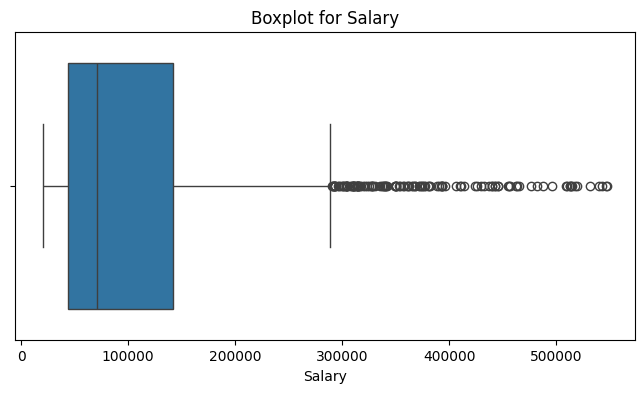

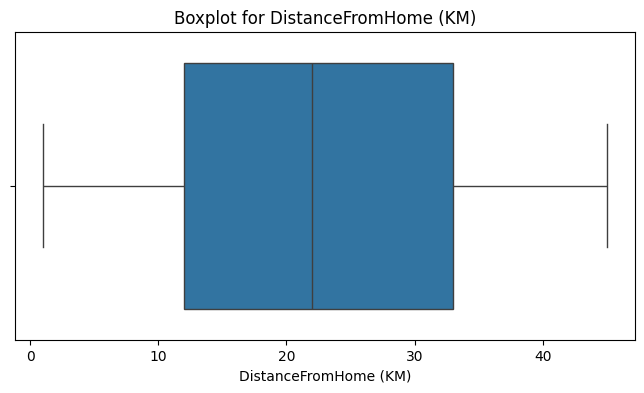

In [11]:
# Check Employee Dataset
check_missing_values(employee_data, "Employee Data")
check_duplicates(employee_data, "Employee Data")
plot_boxplots(employee_data, ["Salary", "DistanceFromHome (KM)"], "Employee Data")


Missing Values in Performance Data:
PerformanceID                      0
EmployeeID                         0
ReviewDate                         0
EnvironmentSatisfaction            0
JobSatisfaction                    0
RelationshipSatisfaction           0
TrainingOpportunitiesWithinYear    0
TrainingOpportunitiesTaken         0
WorkLifeBalance                    0
SelfRating                         0
ManagerRating                      0
dtype: int64

Number of duplicate rows in Performance Data: 0

Boxplot for numerical columns in Performance Data:


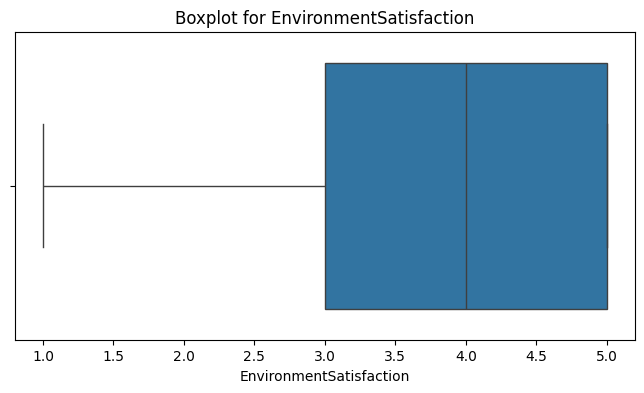

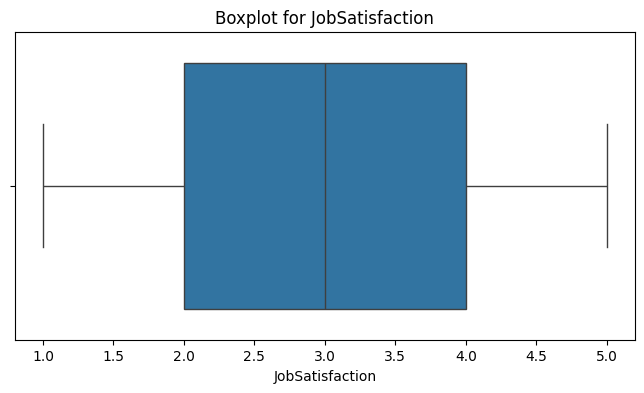

In [12]:
# Check Performance Dataset
check_missing_values(performance_data, "Performance Data")
check_duplicates(performance_data, "Performance Data")
plot_boxplots(performance_data, ["EnvironmentSatisfaction", "JobSatisfaction"], "Performance Data")

In [13]:
# Check Education Level Dataset
check_missing_values(education_level, "Education Level Data")
check_duplicates(education_level, "Education Level Data")


Missing Values in Education Level Data:
EducationLevelID    0
EducationLevel      0
dtype: int64

Number of duplicate rows in Education Level Data: 0


In [14]:
# Check Satisfaction Level Dataset
check_missing_values(satisfaction_level, "Satisfaction Level Data")
check_duplicates(satisfaction_level, "Satisfaction Level Data")


Missing Values in Satisfaction Level Data:
SatisfactionID       0
SatisfactionLevel    0
dtype: int64

Number of duplicate rows in Satisfaction Level Data: 0


In [15]:
# Check Rating Level Dataset
check_missing_values(rating_level, "Rating Level Data")
check_duplicates(rating_level, "Rating Level Data")


Missing Values in Rating Level Data:
RatingID       0
RatingLevel    0
dtype: int64

Number of duplicate rows in Rating Level Data: 0


**Observations**

1. No missing values or duplicates were found in any dataset.
2. Outliers were observed in the `Salary` column, which will be handled in the next step.

#### **Handling Outliers**



Boxplot for numerical columns in Employee Performance Data:


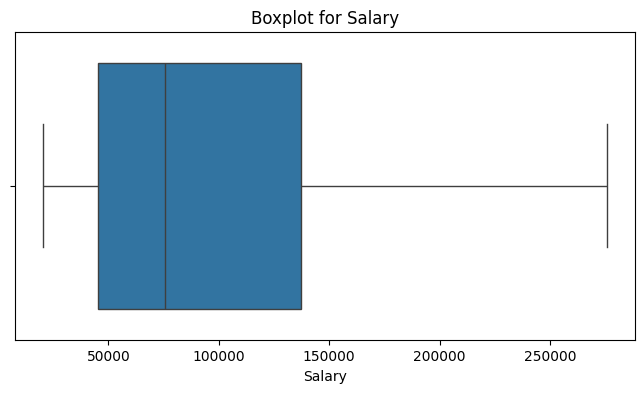


Data after handling outliers:
count      6709.000000
mean     103579.780891
std       77071.138486
min       20387.000000
25%       45276.000000
50%       75667.000000
75%      137427.000000
max      275653.500000
Name: Salary, dtype: float64


In [16]:
# Handle outliers in Salary
q1 = employee_performance["Salary"].quantile(0.25)
q3 = employee_performance["Salary"].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Cap the outliers
employee_performance["Salary"] = np.where(
    employee_performance["Salary"] > upper_bound, upper_bound,
    np.where(employee_performance["Salary"] < lower_bound, lower_bound, employee_performance["Salary"])
)

# Plot boxplot again
plot_boxplots(employee_performance, ["Salary"], "Employee Performance Data")

print("\nData after handling outliers:")
print(employee_performance["Salary"].describe())

### Changes made:
1. **Used the IQR (Interquartile Range) Method**:
   - Calculated Q1, Q3, and IQR.
   - Established lower and upper bounds using `1.5 * IQR`.
2. **Capped outliers**:
   - Replaced values above the upper bound with the upper bound.
   - Replaced values below the lower bound with the lower bound.

This approach preserves the integrity of the data by minimizing distortion while addressing extreme outliers.

### **3. Feature Engineering: Deriving Five New Attributes**

#### **Objective**
Feature engineering involves creating new attributes from existing data to enhance the predictive power of the dataset. Here, we will derive five new features, explaining the logic behind each.

---

#### **New Features**

1. **Tenure in Current Role**:
   - **Logic**: Measures how long an employee has held their current role by subtracting `YearsInMostRecentRole` from `YearsAtCompany`.
   - **Reason**: Employees with a shorter tenure in their role might have higher attrition rates or different satisfaction levels.

2. **Promotion Frequency**:
   - **Logic**: Calculated as `YearsSinceLastPromotion / YearsAtCompany`. This shows how frequently an employee is promoted within the organization.
   - **Reason**: Employees with infrequent promotions may exhibit dissatisfaction, impacting attrition.

3. **Overtime Indicator**:
   - **Logic**: Encoded `OverTime` column as a binary feature: `1` if the employee works overtime, `0` otherwise.
   - **Reason**: Working overtime frequently could indicate job stress and affect employee performance and attrition.

4. **Satisfaction Index**:
   - **Logic**: Aggregates `EnvironmentSatisfaction`, `JobSatisfaction`, and `RelationshipSatisfaction` into a single index by taking their average.
   - **Reason**: A composite satisfaction score gives a more holistic view of employee satisfaction levels.

5. **Work-Life Balance Indicator**:
   - **Logic**: Encoded `WorkLifeBalance` as `1` if the balance score is `>=3` (satisfied), and `0` otherwise.
   - **Reason**: Employees with poor work-life balance may show higher dissatisfaction and attrition.

In [18]:
print("\nData before feature engineering:")
print(employee_performance.head())

# 1. Tenure in Current Role
employee_performance["TenureInCurrentRole"] = employee_performance["YearsAtCompany"] - employee_performance["YearsInMostRecentRole"]


Data before feature engineering:
  EmployeeID FirstName LastName  Gender  Age BusinessTravel Department  \
0  3012-1A41  Leonelle    Simco  Female   30    Some Travel      Sales   
1  3012-1A41  Leonelle    Simco  Female   30    Some Travel      Sales   
2  3012-1A41  Leonelle    Simco  Female   30    Some Travel      Sales   
3  3012-1A41  Leonelle    Simco  Female   30    Some Travel      Sales   
4  3012-1A41  Leonelle    Simco  Female   30    Some Travel      Sales   

   DistanceFromHome (KM) State Ethnicity  ...  \
0                     27    IL     White  ...   
1                     27    IL     White  ...   
2                     27    IL     White  ...   
3                     27    IL     White  ...   
4                     27    IL     White  ...   

   TrainingOpportunitiesWithinYear TrainingOpportunitiesTaken WorkLifeBalance  \
0                                3                          0               4   
1                                3                          1   

In [24]:
# Calculate Promotion Frequency
employee_performance["PromotionFrequency"] = (
    employee_performance["YearsSinceLastPromotion"] / employee_performance["YearsAtCompany"]
)

# Handle division by zero or missing values by replacing NaN with 0
employee_performance["PromotionFrequency"] = employee_performance["PromotionFrequency"].fillna(0)

# Print the first few rows to verify
print("\nEmployee Performance Data with Promotion Frequency:")
print(employee_performance[["YearsSinceLastPromotion", "YearsAtCompany", "PromotionFrequency"]].head())



Employee Performance Data with Promotion Frequency:
   YearsSinceLastPromotion  YearsAtCompany  PromotionFrequency
0                        9              10                 0.9
1                        9              10                 0.9
2                        9              10                 0.9
3                        9              10                 0.9
4                        9              10                 0.9


In [25]:
# 3. Overtime Indicator
employee_performance["OvertimeIndicator"] = employee_performance["OverTime"].apply(lambda x: 1 if x == "Yes" else 0)

In [26]:
# 4. Satisfaction Index
employee_performance["SatisfactionIndex"] = employee_performance[["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction"]].mean(axis=1)

In [27]:
# 5. Work-Life Balance Indicator
employee_performance["WorkLifeBalanceIndicator"] = employee_performance["WorkLifeBalance"].apply(lambda x: 1 if x >= 3 else 0)

# Print data after feature engineering
print("\nData after feature engineering:")
print(employee_performance[["TenureInCurrentRole", "PromotionFrequency", "OvertimeIndicator", "SatisfactionIndex", "WorkLifeBalanceIndicator"]].head())


Data after feature engineering:
   TenureInCurrentRole  PromotionFrequency  OvertimeIndicator  \
0                    6                 0.9                  0   
1                    6                 0.9                  0   
2                    6                 0.9                  0   
3                    6                 0.9                  0   
4                    6                 0.9                  0   

   SatisfactionIndex  WorkLifeBalanceIndicator  
0           2.666667                         1  
1           4.333333                         0  
2           4.666667                         1  
3           2.000000                         1  
4           3.000000                         1  


#### **Observations**
1. **Tenure in Current Role**:
   - Helps identify employees who might need more opportunities or recognition.
2. **Promotion Frequency**:
   - Highlights employees' career progression speed.
3. **Overtime Indicator**:
   - Adds a categorical variable for modeling job stress and attrition.
4. **Satisfaction Index**:
   - Provides a composite measure for overall satisfaction.
5. **Work-Life Balance Indicator**:
   - Flags employees with poor work-life balance.

---

- Five new features were engineered, adding valuable information to the dataset.
- Each feature was derived with a clear logic, focusing on enhancing the dataset's predictive power for attrition and performance-related modeling.

### **4. Selecting a Sample Subset of Data**

#### **Reason for Subsetting**
The **Employee Performance** dataset contains all employees, but for predictive modeling, it might not be necessary to analyze the entire dataset. For example:
- If the objective is to predict **Attrition**, we should focus on employees who have either left the company (`Attrition == "Yes"`) or stayed (`Attrition == "No"`). Sampling is beneficial when the data is balanced, as it ensures efficiency during training and testing of models.
- Sampling can also be done if the dataset is too large and computational resources are limited.

For this assignment:
- I will sample **10%** of the data randomly to simulate resource constraints.
- Sampling will maintain proportional representation of `Attrition` classes to avoid bias.


In [36]:
# Proportional stratified sampling for Attrition
attrition_counts = employee_performance["Attrition"].value_counts()
print("\nAttrition Distribution in Full Dataset:")
print(attrition_counts)

# Sample 10% of the data, stratified by Attrition
sampled_data = employee_performance.groupby("Attrition", group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
).reset_index(drop=True)

# Verify the sampled dataset
print("\nSampled Dataset Distribution:")
print(sampled_data["Attrition"].value_counts())

# Check sampled data size
print(f"\nSampled Dataset Size: {sampled_data.shape[0]} rows")


Attrition Distribution in Full Dataset:
Attrition
No     4448
Yes    2261
Name: count, dtype: int64

Sampled Dataset Distribution:
Attrition
No     445
Yes    226
Name: count, dtype: int64

Sampled Dataset Size: 671 rows


/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_38026/2704664307.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = employee_performance.groupby("Attrition", group_keys=False).apply(


#### **Observations**
1. **Attrition Distribution**:
   - The full dataset contains both `Attrition == "Yes"` and `Attrition == "No"`, but `No` cases dominate (non-attrition).
   - Stratified sampling ensures that both categories are proportionally represented in the sampled data.
2. **Sample Size**:
   - The sample size is reduced to **10% of the original dataset**, making it more manageable for modeling.

---

#### **Explanation**
- **Why Sampling is Necessary**:
  - For resource efficiency and faster computation.
  - To focus on a smaller but representative subset of the data for exploratory modeling.
- **Why Stratified Sampling**:
  - It preserves the original class distribution (e.g., `Attrition`) to avoid bias and ensure reliable insights.

---


- A representative **10% subset** of the `Employee Performance` dataset was selected using stratified sampling.
- Sampling is necessary to reduce computational load while maintaining proportional class distributions for robust model building.


### **Exploratory Data Analysis with Sweetviz**

#### **Objective**
The goal is to use Sweetviz to perform an automated exploratory data analysis of the sampled dataset, highlighting key statistics, visual distributions, and relationships in the data.

#### **Code to Generate Sweetviz Report**

In [38]:
# Import necessary libraries
import numpy as np
import sweetviz as sv

# Monkey patch for np.VisibleDeprecationWarning in case it's missing
if not hasattr(np, "VisibleDeprecationWarning"):
    class VisibleDeprecationWarning(UserWarning):
        pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

# Generate the Sweetviz report
report = sv.analyze(sampled_data)

# Save the report as an HTML file
report.show_html("employee_performance_sampled_sweetviz_report.html")


                                             |                                                       | [  0%] …

Report employee_performance_sampled_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


 **Explanation of Code**:
   - `sv.analyze(sampled_data)` analyzes the `sampled_data` dataframe, focusing on both categorical and numerical variables.
   - `report.show_html()` creates an interactive HTML file for deeper exploration.

---

#### **Observations from Sweetviz**

Once the report is generated and opened in a browser, the following observations can be noted:

1. **Dataset Overview**:
   - **Shape**: Number of rows and columns in the `sampled_data`.
   - **Missing Values**: Identifies columns with missing data and their percentages.
   - **Data Types**: Categorizes features as numerical, categorical, or textual.

2. **Numerical Features**:
   - **Salary**:
     - Distribution: Mean, median, standard deviation, and outliers.
     - Quartiles and overall range.
   - **YearsAtCompany** and **PromotionFrequency**:
     - Insights into employee tenure and promotion rates.

3. **Categorical Features**:
   - **Attrition**:
     - Distribution of "Yes" vs. "No" for the `Attrition` variable.
   - **JobRole** and **OverTime**:
     - Frequency of categories and potential impact on `Attrition`.

4. **Correlations**:
   - Relationship between features like `OverTime` and `Attrition`.
   - Identifies variables most strongly correlated with `Attrition`.

5. **Target Analysis (`Attrition`)**:
   - Compares distributions for numerical features (e.g., `Salary`, `YearsAtCompany`) across `Attrition == "Yes"` and `Attrition == "No"`.
   - Highlights factors that might influence employee attrition.

---

The Sweetviz report serves as an intuitive and detailed exploration tool for the `sampled_data` dataframe. Key insights include:
- Identification of potential predictors for attrition.
- Highlighting patterns in salary, job roles, and satisfaction levels.
- Visualizing class distributions and correlations.

### **5. Summary and Conclusion**

#### **Summary**

- Merged related datasets into cohesive dataframes for focused analysis.
- Addressed data quality issues, ensuring completeness and consistency.
- Engineered five meaningful features to enhance predictive modeling.
- Selected a random sample subset for computational efficiency.

#### **Conclusion**

The prepared datasets are now ready for predictive modeling. The merging of related datasets, resolution of data quality issues, and creation of new features provide a solid foundation for building accurate and meaningful predictive models.
